In [10]:
import pandas as pd 
import os 
import seaborn as sns
import matplotlib.pyplot as plt

# Change directory
os.chdir('/Users/philipp/desktop/ML_in_Applied_Settings')
# print current directory
print(os.getcwd())

# optimize printed dataframes
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

/Users/philipp/Desktop/ML_in_Applied_Settings


In [11]:
# load in dataframe
df_train = pd.read_csv("train.csv", sep=";")
df_train.head()

,rating,title,text,category,ai_generated
0,2,Disappointing battery,"The features are okay, but the battery barely ...",Electronics,1
1,5,Love this pillow case.,I've bought the brand of pillow case many time...,Home_and_Kitchen,0
2,5,Fits a big guy!,[[VIDEOID:35d1cafd2b619e98d3493d14e73e84f4]] H...,Clothing_Shoes_and_Jewelry,0
3,5,Mums the word,This flower is much darker than red. It is sti...,Home_and_Kitchen,0
4,3,Leaks a bit.,"It boils water very quickly, which is great, b...",Home_and_Kitchen,1


In [44]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   rating        7000 non-null   int64 
 1   title         7000 non-null   object
 2   text          7000 non-null   object
 3   category      7000 non-null   object
 4   ai_generated  7000 non-null   int64 
 5   text_length   7000 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 328.3+ KB


In [ ]:
df_train.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   rating        7000 non-null   int64 
 1   title         7000 non-null   object
 2   text          7000 non-null   object
 3   category      7000 non-null   object
 4   ai_generated  7000 non-null   int64 
 5   text_length   7000 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 328.3+ KB


In [42]:
df_train.describe()

,rating,ai_generated,text_length
count,7000.000000,7000.000000,7000.000000
mean,4.252000,0.500000,174.602000
std,1.275545,0.500036,241.684699
min,1.000000,0.000000,4.000000
25%,4.000000,0.000000,69.000000
50%,5.000000,0.500000,125.000000
75%,5.000000,1.000000,184.000000
max,5.000000,1.000000,5092.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   rating        7000 non-null   int64 
 1   title         7000 non-null   object
 2   text          7000 non-null   object
 3   category      7000 non-null   object
 4   ai_generated  7000 non-null   int64 
 5   text_length   7000 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 328.3+ KB


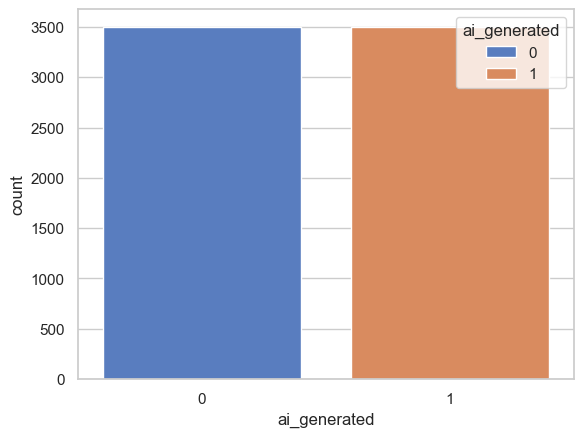

In [27]:
sns.countplot(df_train, x="ai_generated", hue="ai_generated")
plt.show()

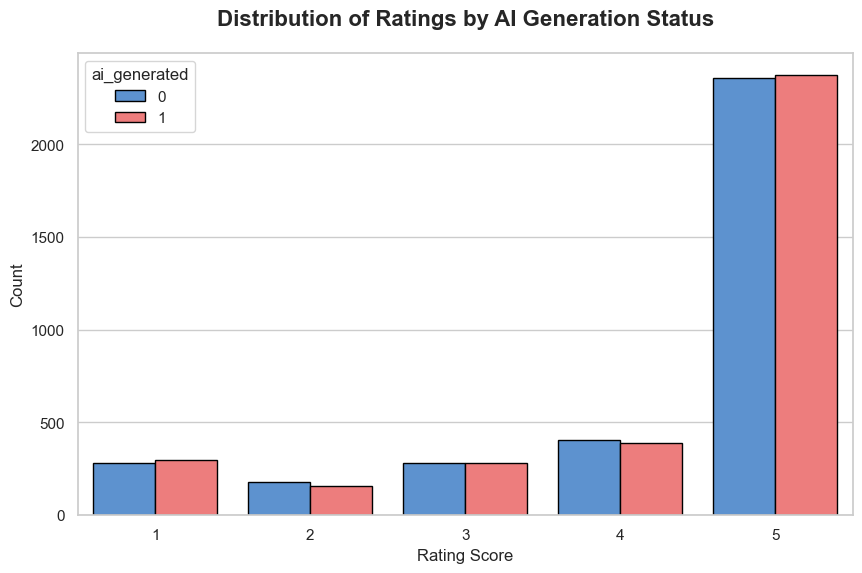

In [19]:
# Set a modern style and color palette
colors = ["#4A90E2", "#FF6B6B"] # Modern blue and soft red/coral
plt.figure(figsize=(10, 6))

# Create the countplot with improved aesthetics
ax = sns.countplot(
    data=df_train, 
    x="rating", 
    hue="ai_generated", 
    edgecolor="black",
    palette=colors
)

# Add title and labels
plt.title("Distribution of Ratings by AI Generation Status", fontsize=16, pad=20, fontweight='bold')
plt.xlabel("Rating Score", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()

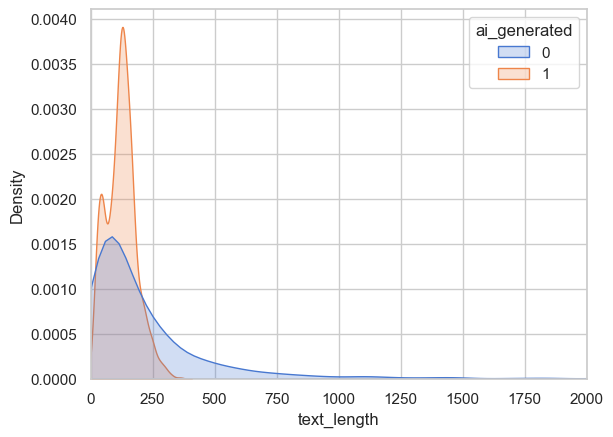

In [25]:
df_train["text_length"] = df_train["text"].apply(lambda x: len(x))
df_train.head()
sns.kdeplot(df_train, x="text_length", hue="ai_generated", fill=True)
plt.xlim(0,2000)
plt.show()

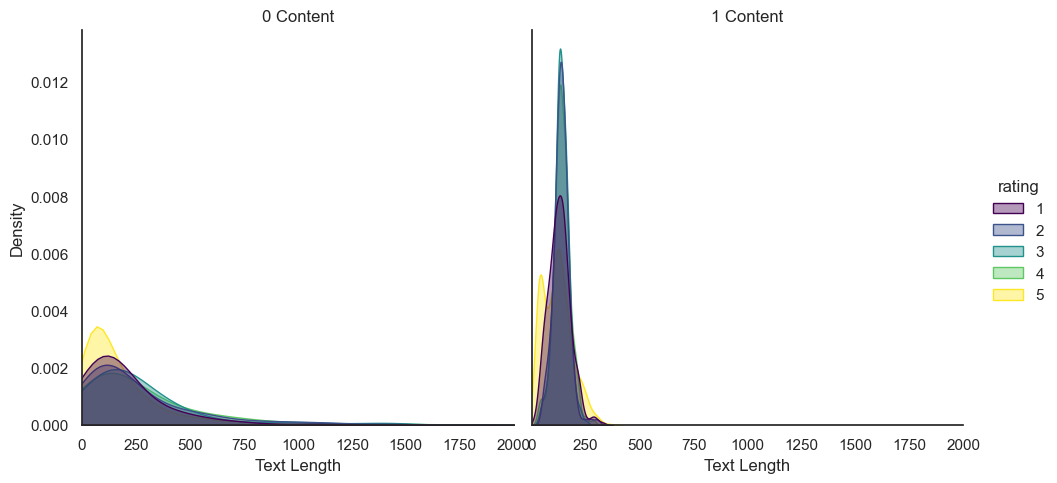

In [ ]:
# Set a clean style
sns.set_theme(style="white")

# Use displot with 'col' to split by AI generation status
g = sns.displot(
    data=df_train, 
    x="text_length", 
    hue="rating", 
    col="ai_generated", 
    kind="kde", 
    fill=True, 
    palette="viridis",
    common_norm=False, # Normalizes each curve individually
    alpha=0.4
)

# Set limits for all subplots
g.set(xlim=(0, 2000))

# Modernize titles and labels
g.set_titles("{col_name} Content")
g.set_axis_labels("Text Length", "Density")

plt.show()